In [1]:
import pandas as pd

# Load all datasets
df_weather = pd.read_csv("../data/processed/weather_clean.csv")
df_ndvi    = pd.read_csv("../data/processed/ndvi_clean.csv")
df_soil    = pd.read_csv("../data/processed/soil_clean.csv")
df_yield   = pd.read_csv("../data/raw/yield_data.csv")
df_seeds   = pd.read_csv("../data/processed/seeds_clean.csv")

print("✓ All files loaded")
print(f"  Weather:  {df_weather.shape}")
print(f"  NDVI:     {df_ndvi.shape}")
print(f"  Soil:     {df_soil.shape}")
print(f"  Yield:    {df_yield.shape}")
print(f"  Seeds:    {df_seeds.shape}")

✓ All files loaded
  Weather:  (20, 10)
  NDVI:     (20, 3)
  Soil:     (1, 5)
  Yield:    (20, 5)
  Seeds:    (20, 7)


In [5]:
# ── MERGE ALL DATASETS ───────────────────────────────────────

# Start with weather as base (20 years)
master = df_weather.copy()

# Merge NDVI
master = master.merge(df_ndvi, on="Year", how="left")

# Merge yield
master = master.merge(
    df_yield[["Year","Area_Ha","Yield_MT_Ha","Production_MT","Source"]], 
    on="Year", how="left"
)

# Merge seeds
master = master.merge(
    df_seeds[["Year","Dominant_Variety","Yield_Potential_Mid","Maturity_Months"]],
    on="Year", how="left"
)

# Add soil as constant columns (same value every row)
master["Soil_pH"]         = df_soil["Soil_pH"].values[0]
master["Soil_Nitrogen"]   = df_soil["Nitrogen_gkg"].values[0]
master["Clay_Pct"]        = df_soil["Clay_Pct"].values[0]
master["Organic_Carbon"]  = df_soil["Organic_Carbon"].values[0]

# Encode seed variety as number for ML
variety_map = {"H614D": 1, "DH04": 2, "DK8031": 3, "H6213": 4}
master["Variety_Code"] = master["Dominant_Variety"].map(variety_map)

# Reorder columns nicely
master = master[[
    "Year",
    # Target
    "Yield_MT_Ha",
    # Weather
    "Rainfall_mm", "Rainfall_LongRains_mm", "Rainfall_ShortRains_mm",
    "Temp_Avg_C", "Temp_Max_C", "Temp_Min_C",
    "Solar_Radiation", "Humidity_Pct", "Soil_Wetness",
    # Satellite
    "NDVI_LongRains", "NDVI_ShortRains",
    # Soil
    "Soil_pH", "Soil_Nitrogen", "Clay_Pct", "Organic_Carbon",
    # Seed
    "Dominant_Variety", "Variety_Code", "Yield_Potential_Mid", "Maturity_Months",
    # Supporting
    "Area_Ha", "Production_MT", "Source"
]]

print(f"✓ Master dataset shape: {master.shape}")
print(f"\nMissing values per column:")
print(master.isnull().sum()[master.isnull().sum() > 0])
print(f"\nFull dataset:")
print(master.to_string(index=False))

# Save
master.to_csv("../data/processed/master_dataset.csv", index=False)
print("\n✓ Saved master_dataset.csv")

✓ Master dataset shape: (20, 24)

Missing values per column:
Yield_MT_Ha      1
Area_Ha          1
Production_MT    1
dtype: int64

Full dataset:
 Year  Yield_MT_Ha  Rainfall_mm  Rainfall_LongRains_mm  Rainfall_ShortRains_mm  Temp_Avg_C  Temp_Max_C  Temp_Min_C  Solar_Radiation  Humidity_Pct  Soil_Wetness  NDVI_LongRains  NDVI_ShortRains  Soil_pH  Soil_Nitrogen  Clay_Pct  Organic_Carbon Dominant_Variety  Variety_Code  Yield_Potential_Mid  Maturity_Months  Area_Ha  Production_MT        Source
 2005     2.100000         3.41                  14.64                    7.13       19.66       33.93        9.95            22.14         68.54          0.53          0.2555           0.1840     6.05          3.245      40.0           36.85            H614D             1                  7.0              6.5  75000.0  157500.000000     Estimated
 2006     2.250000         4.79                  17.77                   23.09       19.50       32.79       12.33            21.41         71.99         

✓ Modelling rows: 19 years (2005–2023)
✓ Features ready: 23

Yield statistics:
  Min:  2.100 t/ha
  Max:  4.259 t/ha
  Mean: 3.149 t/ha


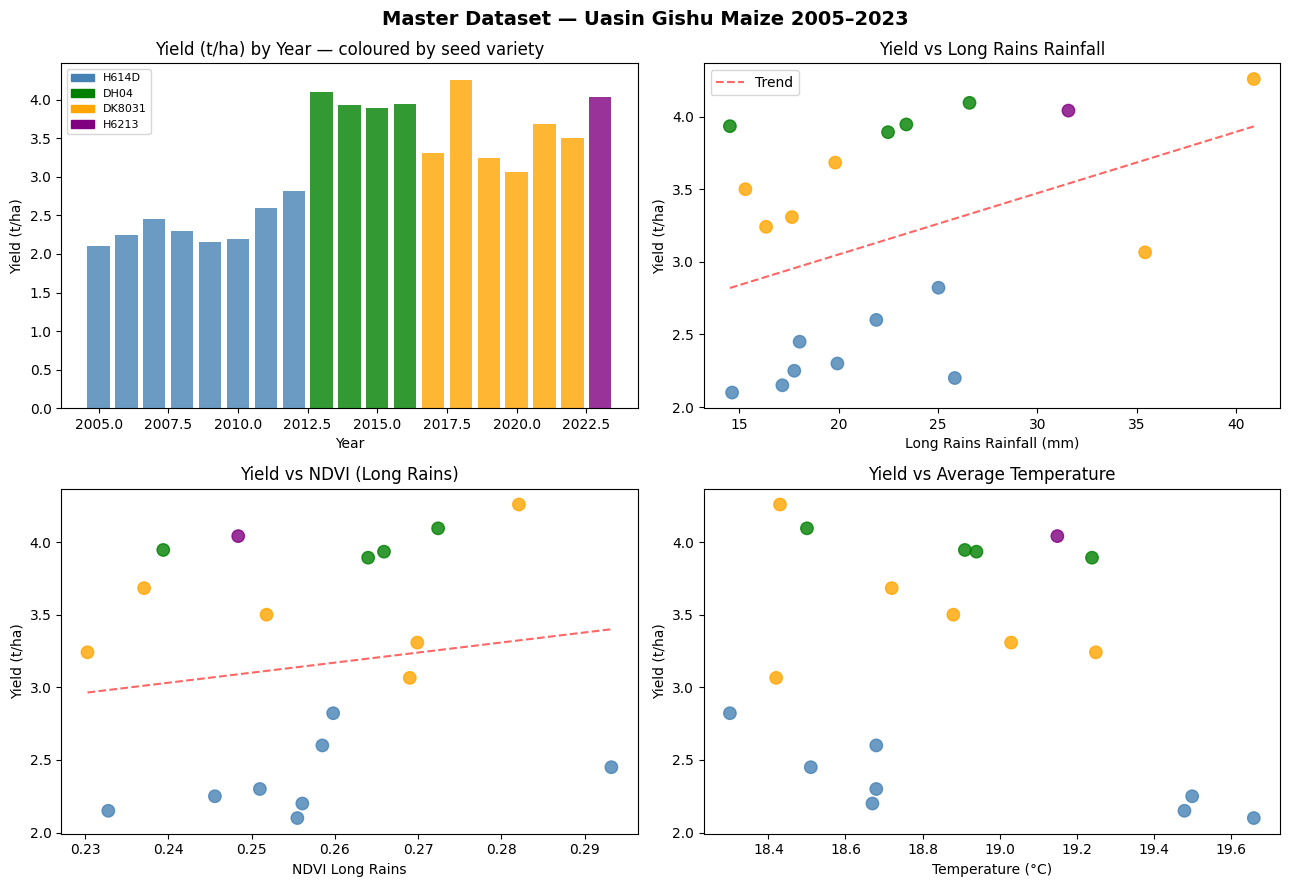

✓ Chart saved to outputs/master_dataset_overview.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Drop 2024 for analysis (no yield yet)
df_model = master.dropna(subset=["Yield_MT_Ha"]).copy()

print(f"✓ Modelling rows: {len(df_model)} years (2005–2023)")
print(f"✓ Features ready: {len(df_model.columns) - 1}")
print(f"\nYield statistics:")
print(f"  Min:  {df_model['Yield_MT_Ha'].min():.3f} t/ha")
print(f"  Max:  {df_model['Yield_MT_Ha'].max():.3f} t/ha")
print(f"  Mean: {df_model['Yield_MT_Ha'].mean():.3f} t/ha")

# Plot yield over time with seed variety coloring
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Master Dataset — Uasin Gishu Maize 2005–2023", 
             fontsize=14, fontweight="bold")

# 1. Yield over time
colors = {"H614D":"steelblue","DH04":"green","DK8031":"orange","H6213":"purple"}
for _, row in df_model.iterrows():
    axes[0,0].bar(row["Year"], row["Yield_MT_Ha"],
                  color=colors[row["Dominant_Variety"]], alpha=0.8)
axes[0,0].set_title("Yield (t/ha) by Year — coloured by seed variety")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Yield (t/ha)")
# Legend
from matplotlib.patches import Patch
legend = [Patch(color=c, label=v) for v,c in colors.items()]
axes[0,0].legend(handles=legend, fontsize=8)

# 2. Yield vs Long Rains Rainfall
axes[0,1].scatter(df_model["Rainfall_LongRains_mm"], df_model["Yield_MT_Ha"],
                  c=[list(colors.values())[v-1] for v in df_model["Variety_Code"]],
                  s=80, alpha=0.8)
axes[0,1].set_title("Yield vs Long Rains Rainfall")
axes[0,1].set_xlabel("Long Rains Rainfall (mm)")
axes[0,1].set_ylabel("Yield (t/ha)")
# Trend line
z = np.polyfit(df_model["Rainfall_LongRains_mm"], df_model["Yield_MT_Ha"], 1)
p = np.poly1d(z)
x_line = np.linspace(df_model["Rainfall_LongRains_mm"].min(),
                     df_model["Rainfall_LongRains_mm"].max(), 100)
axes[0,1].plot(x_line, p(x_line), "r--", alpha=0.6, label="Trend")
axes[0,1].legend()

# 3. Yield vs NDVI Long Rains
axes[1,0].scatter(df_model["NDVI_LongRains"], df_model["Yield_MT_Ha"],
                  c=[list(colors.values())[v-1] for v in df_model["Variety_Code"]],
                  s=80, alpha=0.8)
axes[1,0].set_title("Yield vs NDVI (Long Rains)")
axes[1,0].set_xlabel("NDVI Long Rains")
axes[1,0].set_ylabel("Yield (t/ha)")
z2 = np.polyfit(df_model["NDVI_LongRains"], df_model["Yield_MT_Ha"], 1)
p2 = np.poly1d(z2)
x2 = np.linspace(df_model["NDVI_LongRains"].min(),
                 df_model["NDVI_LongRains"].max(), 100)
axes[1,0].plot(x2, p2(x2), "r--", alpha=0.6)

# 4. Yield vs Temperature
axes[1,1].scatter(df_model["Temp_Avg_C"], df_model["Yield_MT_Ha"],
                  c=[list(colors.values())[v-1] for v in df_model["Variety_Code"]],
                  s=80, alpha=0.8)
axes[1,1].set_title("Yield vs Average Temperature")
axes[1,1].set_xlabel("Temperature (°C)")
axes[1,1].set_ylabel("Yield (t/ha)")

plt.tight_layout()
plt.savefig("../outputs/master_dataset_overview.png", dpi=150)
plt.show()
print("✓ Chart saved to outputs/master_dataset_overview.png")

🌽 Yield by Year (top left)
Yields jumped sharply from ~2.2 t/ha (H614D era) to ~3.9 t/ha (DH04/DK8031 era) — seed variety is clearly your strongest predictor. This is a great signal for the model.
🌧 Yield vs Long Rains (top right)
Positive trend — more rainfall generally means better yield. The relationship is real but noisy, meaning rainfall alone doesn't explain everything.
🛰 Yield vs NDVI (bottom left)
Weak positive trend — NDVI adds some signal but isn't dominant on its own. It works better combined with rainfall.
🌡 Yield vs Temperature (bottom right)
No clear pattern — temperature is probably the weakest feature in this dataset. Uasin Gishu's temperatures are too stable to drive big yield differences.